# Analyse des données Netflix

Ce notebook explore le catalogue Netflix (films et séries) : répartition
des contenus, évolution dans le temps, durées, saisons, catégories,
réalisateurs et acteurs.

**Structure**
1. Imports et configuration
2. Chargement et préparation des données
3. Répartition des types de contenu
4. Évolution des contenus ajoutés
5. Durées des films
6. Nombre de saisons des séries
7. Catégories les plus représentées
8. Réalisateurs les plus présents
9. Acteurs associés à un réalisateur
10. Exécution de l'analyse complète


In [1]:
# ============================================================
# 1. IMPORTS ET CONFIGURATION
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Style graphique appliqué à l'ensemble du notebook
sns.set_theme(style="whitegrid")

# Paramètres réutilisés par les fonctions de tracé
FIGSIZE_SMALL = (8, 5)
FIGSIZE_MEDIUM = (10, 6)
FIGSIZE_LARGE = (12, 6)
TOP_N_DEFAULT = 10

# Colonnes indispensables à l'analyse : on échoue tôt et clairement
# si le CSV fourni ne correspond pas au format attendu.
REQUIRED_COLUMNS = [
    "type", "title", "director", "cast", "rating",
    "duration", "date_added", "release_year", "listed_in",
]


In [2]:
# ============================================================
# 2. CONFIGURATION DU CHEMIN VERS LE DATASET
# ============================================================

# Adapter ce chemin selon l'environnement d'exécution.
# Utiliser un chemin relatif ou une variable d'environnement rend le
# notebook portable (contrairement à un chemin Windows absolu en dur).
FILEPATH = Path("netflix_titles.csv")


In [3]:
# ============================================================
# 3. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ============================================================

def load_data(filepath: Path) -> pd.DataFrame:
    """
    Charge le dataset Netflix depuis un fichier CSV et vérifie
    que les colonnes attendues sont présentes.

    Parameters
    ----------
    filepath : Path
        Chemin vers le fichier CSV.

    Returns
    -------
    pd.DataFrame
        Dataset chargé.

    Raises
    ------
    FileNotFoundError
        Si le fichier n'existe pas.
    ValueError
        Si une colonne attendue est absente du fichier.
    """

    filepath = Path(filepath)

    if not filepath.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {filepath}. "
            "Vérifiez la variable FILEPATH."
        )

    df = pd.read_csv(filepath)

    colonnes_manquantes = set(REQUIRED_COLUMNS) - set(df.columns)
    if colonnes_manquantes:
        raise ValueError(
            f"Colonnes manquantes dans le dataset : {colonnes_manquantes}"
        )

    return df


def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prépare les variables nécessaires à l'analyse.

    - Corrige les durées mal enregistrées dans `rating`
      (décalage de colonnes fréquent dans ce dataset).
    - Convertit `date_added` en datetime.
    - Crée `year_added`.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset Netflix brut.

    Returns
    -------
    pd.DataFrame
        Dataset nettoyé et enrichi.
    """

    df = df.copy()

    # --------------------------------------------------------
    # Correction des durées mal enregistrées dans rating
    # --------------------------------------------------------

    erreur_duration = df["rating"].str.contains("min", na=False)

    df.loc[erreur_duration, "duration"] = df.loc[erreur_duration, "rating"]
    df.loc[erreur_duration, "rating"] = pd.NA

    # --------------------------------------------------------
    # Conversion de la date d'ajout
    # --------------------------------------------------------

    df["date_added"] = pd.to_datetime(
        df["date_added"],
        format="mixed",
        errors="coerce",
    )

    df["year_added"] = df["date_added"].dt.year

    return df


In [4]:
# ============================================================
# 4. OUTIL DE MISE EN FORME DES GRAPHIQUES
# ============================================================

def finalize_plot(title: str, xlabel: str, ylabel: str) -> None:
    """
    Applique titre, labels et mise en page à la figure courante,
    puis l'affiche. Évite de répéter ce bloc dans chaque fonction
    de tracé.
    """

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


In [5]:
# ============================================================
# 5. ANALYSE DU TYPE DE CONTENU
# ============================================================

def count_content_types(df: pd.DataFrame) -> pd.Series:
    """
    Compte le nombre de contenus par type.

    Returns
    -------
    pd.Series
        Nombre de contenus par type.
    """
    return df["type"].value_counts()


def plot_content_types(df: pd.DataFrame) -> None:
    """
    Affiche la répartition des contenus Movie / TV Show.
    """

    plt.figure(figsize=FIGSIZE_SMALL)

    ax = sns.countplot(
        data=df,
        x="type",
        order=df["type"].value_counts().index,
    )
    ax.bar_label(ax.containers[0])

    finalize_plot(
        "Répartition des contenus Netflix",
        "Type de contenu",
        "Nombre de contenus",
    )


In [6]:
# ============================================================
# 6. ÉVOLUTION DES CONTENUS AJOUTÉS
# ============================================================

def contents_added_by_year(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcule le nombre de contenus ajoutés par année et par type.

    Les lignes sans date d'ajout exploitable (year_added manquant)
    sont exclues du comptage.

    Returns
    -------
    pd.DataFrame
        Nombre de contenus par année et par type.
    """

    return (
        df
        .dropna(subset=["year_added"])
        .groupby(["year_added", "type"])
        .size()
        .reset_index(name="nombre_contenus")
    )


def plot_contents_added_by_year(df: pd.DataFrame) -> None:
    """
    Trace l'évolution du nombre de contenus ajoutés
    sur Netflix au fil des années.
    """

    data = contents_added_by_year(df)

    plt.figure(figsize=FIGSIZE_LARGE)

    sns.lineplot(
        data=data,
        x="year_added",
        y="nombre_contenus",
        hue="type",
        marker="o",
    )

    plt.xticks(rotation=45)
    finalize_plot(
        "Évolution du nombre de contenus ajoutés sur Netflix",
        "Année d'ajout",
        "Nombre de contenus",
    )


In [7]:
# ============================================================
# 7. ANALYSE DES DURÉES DES FILMS
# ============================================================

def prepare_movie_durations(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extrait les films et convertit leur durée en minutes.

    Les films sans durée renseignée sont écartés.

    Returns
    -------
    pd.DataFrame
        DataFrame contenant les films et leur durée numérique.
    """

    movies = df.loc[df["type"] == "Movie"].dropna(subset=["duration"]).copy()

    movies["duration_min"] = (
        movies["duration"]
        .str.replace(" min", "", regex=False)
        .astype(float)
    )

    return movies


def get_longest_movie(df: pd.DataFrame) -> pd.Series:
    """
    Retourne le film ayant la plus longue durée.

    Note : en cas d'égalité, seul le premier film rencontré est
    retourné (comportement de `Series.idxmax`).
    """

    movies = prepare_movie_durations(df)
    index_longest = movies["duration_min"].idxmax()

    return movies.loc[index_longest, ["title", "duration", "release_year"]]


def plot_movie_duration_distribution(df: pd.DataFrame) -> None:
    """
    Affiche la distribution des durées des films.
    """

    movies = prepare_movie_durations(df)

    plt.figure(figsize=FIGSIZE_MEDIUM)

    sns.histplot(data=movies, x="duration_min", kde=True)

    finalize_plot(
        "Distribution de la durée des films",
        "Durée (minutes)",
        "Nombre de films",
    )


In [8]:
# ============================================================
# 8. ANALYSE DU NOMBRE DE SAISONS DES SÉRIES
# ============================================================

def prepare_tv_shows(df: pd.DataFrame) -> pd.DataFrame:
    """
    Sélectionne uniquement les séries et extrait le nombre
    de saisons sous forme numérique.

    Returns
    -------
    pd.DataFrame
        DataFrame contenant les séries et leur nombre de saisons.
    """

    tv_shows = df.loc[df["type"] == "TV Show"].dropna(subset=["duration"]).copy()

    tv_shows["nombre_saisons"] = (
        tv_shows["duration"]
        .str.extract(r"(\d+)")
        .astype(float)
    )

    return tv_shows


def count_shows_by_seasons(df: pd.DataFrame) -> pd.Series:
    """
    Compte le nombre de séries pour chaque nombre de saisons.

    Returns
    -------
    pd.Series
        Nombre de séries par nombre de saisons, trié par nombre
        de saisons croissant.
    """

    tv_shows = prepare_tv_shows(df)

    return (
        tv_shows["nombre_saisons"]
        .value_counts()
        .sort_index()
    )


def plot_shows_by_seasons(df: pd.DataFrame) -> None:
    """
    Affiche le nombre de séries selon leur nombre de saisons.

    Le nombre de saisons est converti en chaîne de caractères
    avant le tracé : cela force seaborn à le traiter comme une
    catégorie sur l'axe y plutôt que comme une variable numérique,
    ce qui évite une agrégation indésirable lorsque plusieurs
    nombres de saisons partagent le même nombre de séries.
    """

    data = count_shows_by_seasons(df)

    plt.figure(figsize=FIGSIZE_MEDIUM)

    ax = sns.barplot(
        x=data.values,
        y=data.index.astype(int).astype(str),
    )
    ax.bar_label(ax.containers[0])

    finalize_plot(
        "Nombre de séries selon le nombre de saisons",
        "Nombre de séries",
        "Nombre de saisons",
    )


In [9]:
# ============================================================
# 9. ANALYSE DES CATÉGORIES
# ============================================================

def get_top_categories(df: pd.DataFrame, n: int = TOP_N_DEFAULT) -> pd.Series:
    """
    Retourne les catégories les plus représentées.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset Netflix.
    n : int
        Nombre de catégories à retourner.

    Returns
    -------
    pd.Series
        Top n des catégories.
    """

    categories = (
        df["listed_in"]
        .dropna()
        .str.split(", ")
        .explode()
    )

    return categories.value_counts().head(n)


In [10]:
# ============================================================
# 10. ANALYSE DES RÉALISATEURS
# ============================================================

def get_top_directors(df: pd.DataFrame, n: int = TOP_N_DEFAULT) -> pd.Series:
    """
    Retourne les réalisateurs les plus présents dans le dataset.
    """

    directors = (
        df["director"]
        .dropna()
        .str.split(", ")
        .explode()
    )

    return directors.value_counts().head(n)


In [11]:
# ============================================================
# 11. ANALYSE DES ACTEURS D'UN RÉALISATEUR
# ============================================================

def get_director_actors(
    df: pd.DataFrame,
    director_name: str,
    n: int = 5,
) -> pd.Series:
    """
    Retourne les acteurs les plus présents dans les contenus
    d'un réalisateur donné.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset Netflix.
    director_name : str
        Nom (ou partie du nom) du réalisateur.
    n : int
        Nombre d'acteurs à retourner.

    Returns
    -------
    pd.Series
        Acteurs les plus fréquents. Vide si le réalisateur
        n'est pas trouvé dans le dataset.
    """

    director_data = df.loc[
        df["director"].notna()
        & df["director"].str.contains(director_name, case=False, na=False)
    ]

    if director_data.empty:
        print(f"Aucun contenu trouvé pour le réalisateur : {director_name!r}")
        return pd.Series(dtype="int64")

    actors = (
        director_data["cast"]
        .dropna()
        .str.split(", ")
        .explode()
    )

    return actors.value_counts().head(n)


In [12]:
# ============================================================
# 12. ORCHESTRATION DE L'ANALYSE COMPLÈTE
# ============================================================

def run_analysis(filepath: Path, director_name: str = "Jan Suter") -> pd.DataFrame:
    """
    Exécute l'ensemble de l'analyse et affiche les résultats.

    Parameters
    ----------
    filepath : Path
        Chemin vers le fichier CSV Netflix.
    director_name : str
        Réalisateur utilisé pour l'analyse des acteurs associés.

    Returns
    -------
    pd.DataFrame
        Dataset préparé, pour une exploration complémentaire
        après exécution.
    """

    donnees = prepare_data(load_data(filepath))

    print("Dimensions du dataset :", donnees.shape)
    print("\nTypes de contenus :")
    print(count_content_types(donnees))

    plot_content_types(donnees)
    plot_contents_added_by_year(donnees)

    print("\nFilm le plus long :")
    print(get_longest_movie(donnees))
    plot_movie_duration_distribution(donnees)

    print("\nNombre de séries par nombre de saisons :")
    print(count_shows_by_seasons(donnees))
    plot_shows_by_seasons(donnees)

    print("\nTop", TOP_N_DEFAULT, "catégories :")
    print(get_top_categories(donnees))

    print("\nTop", TOP_N_DEFAULT, "réalisateurs :")
    print(get_top_directors(donnees))

    print(f"\nActeurs les plus fréquents avec {director_name} :")
    print(get_director_actors(donnees, director_name, n=5))

    return donnees


Dimensions du dataset : (8807, 13)

Types de contenus :
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


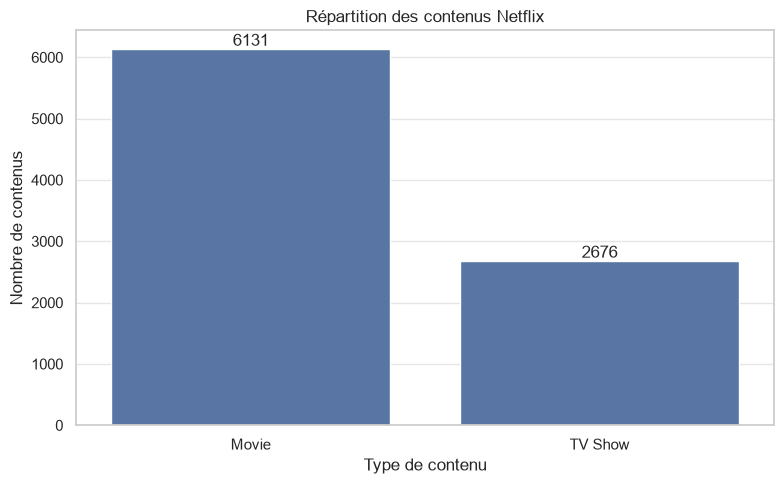

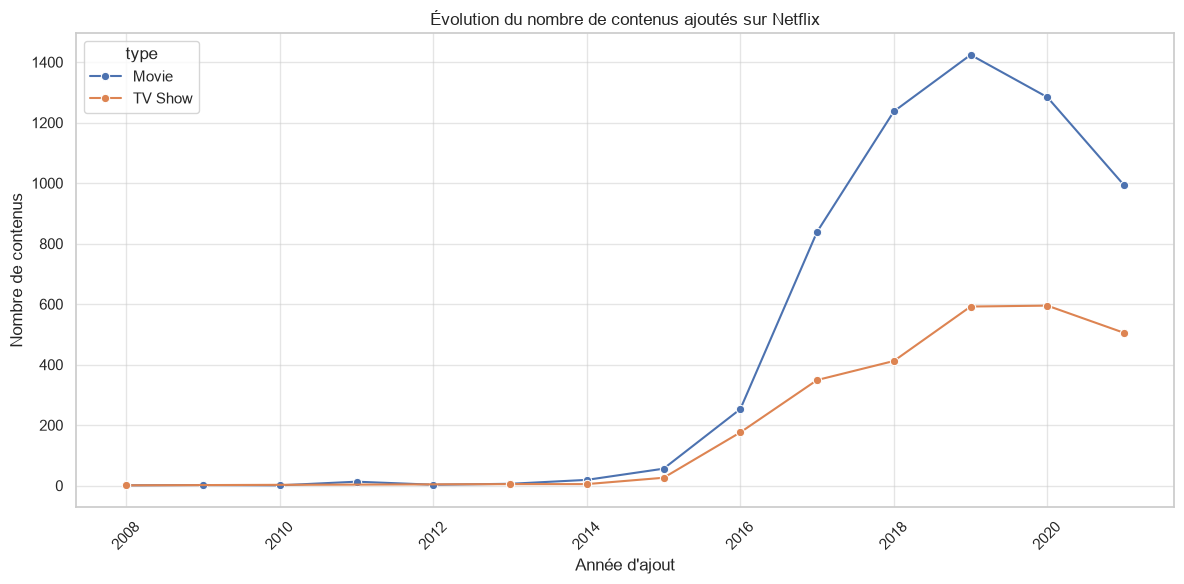


Film le plus long :
title           Black Mirror: Bandersnatch
duration                           312 min
release_year                          2018
Name: 4253, dtype: object


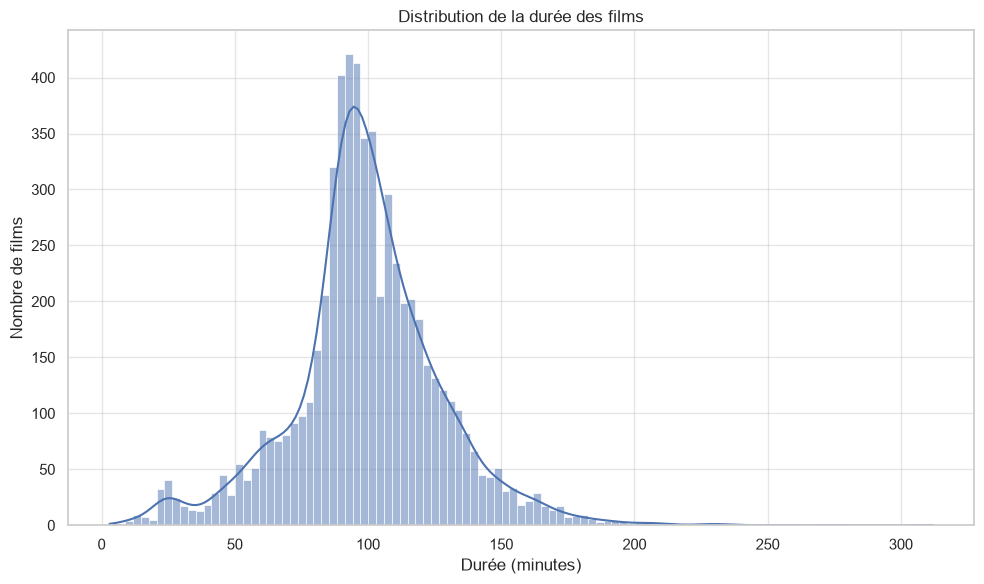


Nombre de séries par nombre de saisons :
nombre_saisons
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64


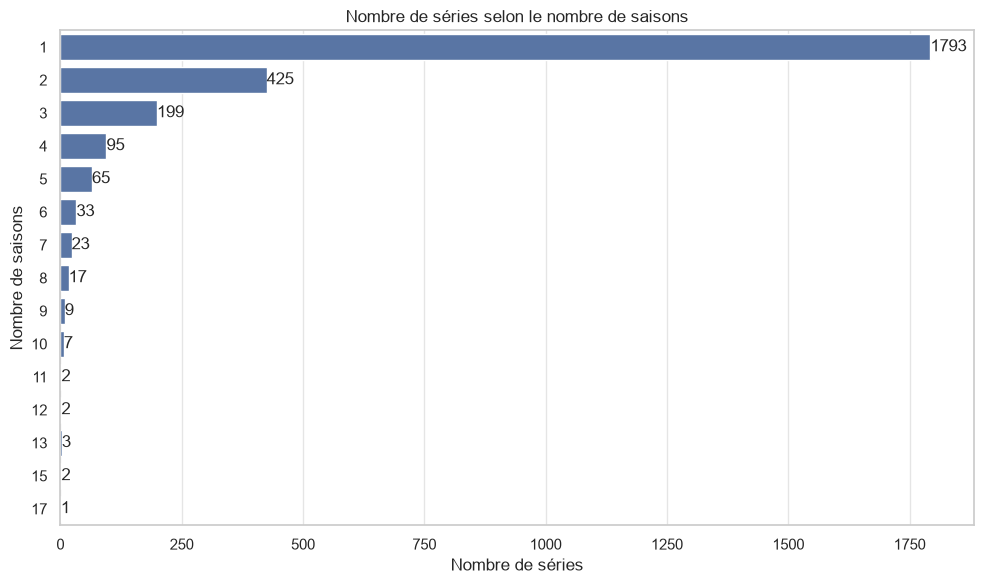


Top 10 catégories :
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

Top 10 réalisateurs :
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

Acteurs les plus fréquents avec Jan Suter :
cast
Carlos Ballarta         3
Sofía Niño de Rivera    3
Ricardo O'Farrill       2
Coco Celis              1
Raúl Meneses            1
Name: count, dtype: int64


In [13]:
# ============================================================
# 13. EXÉCUTION
# ============================================================

donnees = run_analysis(FILEPATH, director_name="Jan Suter")
